In [1]:
#1. Importing the lib
import numpy as np
import pandas as pd


In [2]:
#01. downloading the data

df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/'
    'machine-learning-databases'
    '/breast-cancer-wisconsin/wdbc.data',
    header=None
)
df.to_csv("breast_cancer_wisconsin.csv" , index = False)

In [3]:
df

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
#Label_encoding the M and B
from sklearn.preprocessing import LabelEncoder

#01. selecting the data
X = df.loc[:,2:].values
y= df.loc[:,1].values

#02. Label encoding the vlaues of y
le = LabelEncoder()
y = le.fit_transform(y)
print(np.unique(y))
print(le.classes_)

[0 1]
['B' 'M']


###**Splitting the Data**

In [5]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train, y_test = train_test_split(X , y ,
                                                      test_size=0.2,
                                                      stratify = y,
                                                      random_state = 42)

len(X_train) , len(X_test) , len(y_train) , len(y_test)

(455, 114, 455, 114)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression())
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
print('Test Accuracy: %.3f' % pipe_lr.score(X_test, y_test))

Test Accuracy: 0.947


#**Using the Kfols crossvalidation to asses the model performance**

In [7]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state = 42).split(X_train, y_train)

scores = []

for k , (train,test) in enumerate(kfold):
   # so here k --> 0 ,1, 2, ..9
    # train = array of indices for training (e.g., [2,3,4,5,6,7,8,9])
    # test  = array of indices for testing (e.g., [0,1])
  pipe_lr.fit(X_train[train], y_train[train])
  score = pipe_lr.score(X_train[test], y_train[test])
  scores.append(score)
  print('Fold: %2d, Class dist.: %s, Acc: %.3f' % (k+1,
  np.bincount(y_train[train]), score))

Fold:  1, Class dist.: [256 153], Acc: 0.957
Fold:  2, Class dist.: [256 153], Acc: 0.935
Fold:  3, Class dist.: [256 153], Acc: 0.935
Fold:  4, Class dist.: [256 153], Acc: 0.978
Fold:  5, Class dist.: [256 153], Acc: 0.913
Fold:  6, Class dist.: [257 153], Acc: 0.956
Fold:  7, Class dist.: [257 153], Acc: 0.911
Fold:  8, Class dist.: [257 153], Acc: 0.978
Fold:  9, Class dist.: [257 153], Acc: 0.978
Fold: 10, Class dist.: [257 153], Acc: 0.933


###**`Cross_val_score`**

In [8]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe_lr,
                         X = X_train,
                         y=y_train,
                         cv = 10,
                         n_jobs = -1)
print(f"Accuracy_score {scores}")

Accuracy_score [0.95652174 0.91304348 0.97826087 1.         0.93478261 0.91111111
 0.91111111 0.97777778 0.91111111 0.95555556]


In [9]:
print(f"Cv ACCURACY : {np.mean(scores):.3f} / {np.std(scores):.3f}")

Cv ACCURACY : 0.945 / 0.032


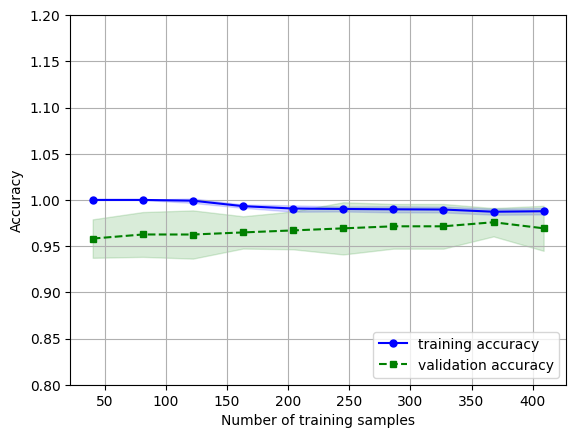

In [10]:
# bias and viariance Curve

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(
                            penalty='l2', #--> ridge , smoothly balance the feature
                            max_iter = 10000
                        ))
train_size , train_score , test_score = learning_curve(estimator = pipe_lr,
                                                       X= X_train,
                                                       y=y_train,
                                                       train_sizes = np.linspace(0.1,1.0,10),
                                                       cv = 10,
                                                       n_jobs = -1)

train_mean = np.mean(train_score, axis = 1)
train_std = np.std(train_score, axis = 1)
test_mean = np.mean(test_score , axis = 1)
test_std = np.std(test_score, axis = 1)

plt.plot(train_size , train_mean, color='blue', marker='o' , markersize=5, label='training accuracy')
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
plt.plot(train_size , test_mean, color='green', linestyle='--', marker='s' , markersize=5, label='validation accuracy')
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
plt.grid()
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.2])
plt.show()

In [11]:
# Tuning hyper parameter by grid search

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=42))

# now creating the parameter for the fine tuning the model
param_range = [0.0001 , 0.001 , 0.01, 0.1, 1.0 , 10.0, 100.0 , 1000.0] # these rae the parameter range

param_grid = [{'svc__C': param_range,
               'svc__kernel':['linear']},
              {
                  'svc__C': param_range,
                  'svc__gamma': param_range,
                  'svc__kernel':['rbf']
              }
              ]
gs = GridSearchCV(estimator=pipe_svc,
                           param_grid=param_grid,
                           scoring = 'accuracy',
                           cv = 10,
                           refit = True,
                           n_jobs = -1)

gs = gs.fit(X_train, y_train)

print(f"The best score is {gs.best_score_}")
print(f"The best parameter is {gs.best_params_}")


The best score is 0.9757004830917875
The best parameter is {'svc__C': 100.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


###Using the 'RandomSearchCV' --> it automatically select the best param for the model  

In [15]:
import scipy
param_range = scipy.stats.loguniform(0.0001, 1000)
param_range

np.random.seed(2)
param_range.rvs(10)

array([1.12710484e-01, 1.51874067e-04, 7.04104865e-01, 1.11495348e-01,
       8.76142232e-02, 2.05278633e-02, 2.70732528e-03, 2.16220449e+00,
       1.25193769e-02, 7.37549080e-03])

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# creating the pipeline as created above

pipe_ran = make_pipeline(StandardScaler(),
                         SVC(random_state=42))

# here we do not need to assign the param_range

param_grid = [{'svc__C': param_range,
               'svc__kernel' : ['linear']},
              {'svc__C': param_range,
               'svc__gamma': param_range,   # 01. controls the distance of influence and curvature of the decision boundary for non-linear kernels like RBF, polynomial, and sigmoid
               'svc__kernel': ['rbf']}]

rs = RandomizedSearchCV(estimator = pipe_ran,
                        cv = 10,
                        param_distributions= param_grid,
                        scoring = 'accuracy',
                        refit = True,
                        random_state = 42,
                        n_iter = 10,
                        n_jobs = -1)
rs = rs.fit(X_train , y_train)
print(f" Random_search best score {rs.best_score_} / And the best parameter are {rs.best_params_}")

 Random_search best score 0.9692270531400966 / And the best parameter are {'svc__C': np.float64(0.010929592787219389), 'svc__kernel': 'linear'}


### **Using the HalvingRandomSearchCV**

this is the best tool for the find the good Ml model setting

In [21]:
# but as it is expermintal we need to import enabler

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

hs = HalvingRandomSearchCV(estimator = pipe_ran,
                           n_candidates='exhaust',
                           factor = 1.5,
                           param_distributions= param_grid,
                           resource= 'n_samples',
                           random_state = 42,
                           n_jobs = -1)
hs = hs.fit(X_train , y_train)
print(f" HalvingRandomSearchCV best score {hs.best_score_} / And the best parameter are {hs.best_params_}")

 HalvingRandomSearchCV best score 0.9676470588235295 / And the best parameter are {'svc__C': np.float64(0.06295450333384245), 'svc__kernel': 'linear'}


In [22]:
clf = hs.best_estimator_
clf.fit(X_train, y_train)
print('Test accuracy: %.3f' % clf.score(X_test, y_test))

Test accuracy: 0.982
